## Mount Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_PATH = "/content/drive/MyDrive/rocket_telemetry_project"
os.chdir(PROJECT_PATH)

print("Current directory:", os.getcwd())

Mounted at /content/drive
Current directory: /content/drive/MyDrive/rocket_telemetry_project


## Imports

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt

## Load Preprocessed Arrays

In [8]:
channel_id = "P-1"

train_path = f"data/processed/{channel_id}_train.npy"
test_path = f"data/processed/{channel_id}_test.npy"

assert os.path.exists(train_path), "Train file missing"
assert os.path.exists(test_path), "Test file missing"

X_train_processed = np.load(train_path)
X_test_processed = np.load(test_path)

print(f"[{channel_id}] Train:", X_train_processed.shape)
print(f"[{channel_id}] Test:", X_test_processed.shape)

[P-1] Train: (2872, 96)
[P-1] Test: (8505, 96)


## WINDOW SIZE SELECTION (ACF METHOD)

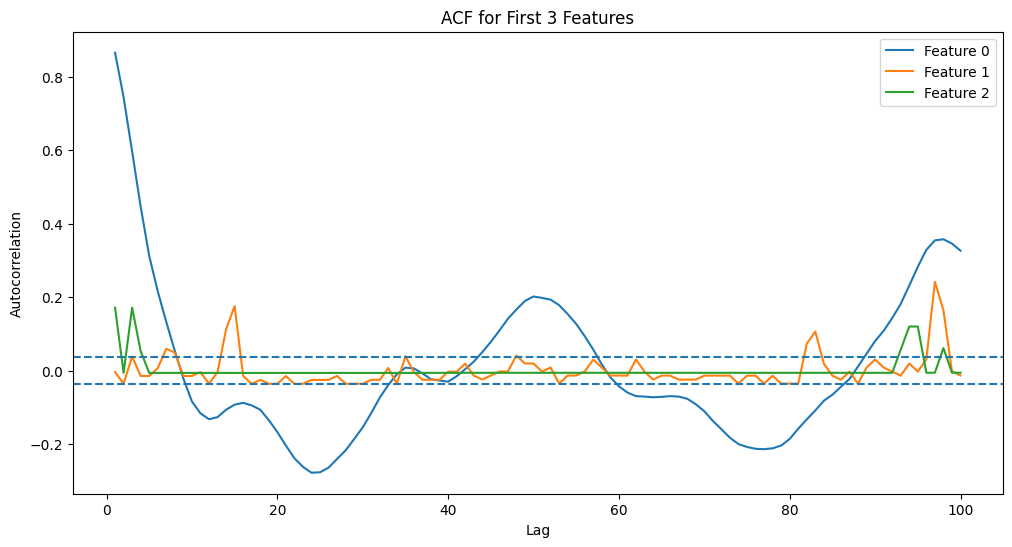

Recommended window size: 41


In [9]:
n = X_train_processed.shape[0]
confidence_band = 1.96 / sqrt(n)

lags = range(1, 101)
feature_lags = []

plt.figure(figsize=(12,6))

for f in range(X_train_processed.shape[1]):

    series = pd.Series(X_train_processed[:, f])
    acf_vals = []

    drop_lag = None

    for k in lags:
        val = series.autocorr(lag=k)
        acf_vals.append(val)

        if drop_lag is None and abs(val) < confidence_band:
            drop_lag = k

    if drop_lag is None:
        drop_lag = 100

    feature_lags.append(drop_lag)

    if f < 3:
        plt.plot(lags, acf_vals, label=f"Feature {f}")

window_size = max(feature_lags)

if window_size > 100:
    window_size = 100

plt.axhline(confidence_band, linestyle="--")
plt.axhline(-confidence_band, linestyle="--")

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("ACF for First 3 Features")
plt.legend()

os.makedirs("results/plots", exist_ok=True)

plt.savefig("results/plots/P1_acf.png", dpi=150)
plt.show()

print("Recommended window size:", window_size)

### Window Size Selection using Autocorrelation Function (ACF)

### To determine an appropriate sequence length for the LSTM model, we analyze the temporal dependency in the training data using the Autocorrelation Function (ACF). The ACF is computed for lags 1–100 for each feature. The confidence bounds (±1.96/√n) indicate the range where autocorrelation becomes statistically insignificant.

### The recommended window size is selected as the maximum lag where the autocorrelation first falls within the confidence bounds across all features. For channel P-1, the ACF drops below the confidence threshold at lag ≈ 41, indicating that dependencies beyond this lag are weak.

### Therefore, the window size is set to 41 timesteps, allowing the model to capture the relevant temporal structure while maintaining computational efficiency.

## create_sequences

In [10]:
def create_sequences(X, window_size=50, step=1):

    if window_size >= len(X):
        raise ValueError("window_size must be smaller than data length")

    sequences = []

    for i in range(0, len(X) - window_size, step):
        window = X[i:i + window_size]
        sequences.append(window)

    sequences = np.array(sequences)

    assert sequences.ndim == 3

    print(f"Input {X.shape} → Output {sequences.shape} | step={step}")

    return sequences

## temporal_train_val_split

In [11]:
def temporal_train_val_split(X_seq, val_ratio=0.1):

    cut = int(len(X_seq) * (1 - val_ratio))

    X_train = X_seq[:cut]
    X_val = X_seq[cut:]

    assert not np.array_equal(X_train[-1], X_val[0])

    print("Train sequences:", X_train.shape)
    print("Validation sequences:", X_val.shape)

    return X_train, X_val

## prepare_all_sequences

In [12]:
def prepare_all_sequences(channel_id, window_size=50, step=1, val_ratio=0.1):

    train_path = f"data/processed/{channel_id}_train.npy"
    test_path = f"data/processed/{channel_id}_test.npy"

    X_train = np.load(train_path)
    X_test = np.load(test_path)

    X_train_seq = create_sequences(X_train, window_size, step)
    X_test_seq = create_sequences(X_test, window_size, step)

    X_tr, X_val = temporal_train_val_split(X_train_seq, val_ratio)

    os.makedirs("data/sequences", exist_ok=True)

    np.save(f"data/sequences/{channel_id}_train_seq.npy", X_tr)
    np.save(f"data/sequences/{channel_id}_val_seq.npy", X_val)
    np.save(f"data/sequences/{channel_id}_test_seq.npy", X_test_seq)

    def mem(x):
        return x.nbytes / (1024 * 1024)

    print("Memory usage (MB)")
    print("Train:", mem(X_tr))
    print("Val:", mem(X_val))
    print("Test:", mem(X_test_seq))

    return X_tr, X_val, X_test_seq

## Generate Sequences

In [13]:
X_tr, X_val, X_te = prepare_all_sequences(
    channel_id,
    window_size=window_size,
    step=1,
    val_ratio=0.1
)

Input (2872, 96) → Output (2831, 41, 96) | step=1
Input (8505, 96) → Output (8464, 41, 96) | step=1
Train sequences: (2547, 41, 96)
Validation sequences: (284, 41, 96)
Memory usage (MB)
Train: 76.484619140625
Val: 8.5283203125
Test: 254.16796875


## SEQUENCE INTEGRITY CHECKS

In [15]:
print("Sequence Integrity Checks")

check1 = np.array_equal(
    X_tr[0],
    X_train_processed[0:window_size]
)

print("Check 1 (first window correct):", "PASS" if check1 else "FAIL")

check2 = not np.array_equal(
    X_tr[-1],
    X_val[0]
)

print("Check 2 (train/val separation):", "PASS" if check2 else "FAIL")

check3 = not (
    np.isnan(X_tr).any() or
    np.isnan(X_val).any() or
    np.isnan(X_te).any()
)

print("Check 3 (no NaN):", "PASS" if check3 else "FAIL")

check4 = (
    X_tr.ndim == 3 and
    X_val.ndim == 3 and
    X_te.ndim == 3
)

print("Check 4 (3D shapes):", "PASS" if check4 else "FAIL")

check5 = np.array_equal(
    X_te[0],
    X_test_processed[0:window_size]
)

print("Check 5 (test window correct):", "PASS" if check5 else "FAIL")

Sequence Integrity Checks
Check 1 (first window correct): PASS
Check 2 (train/val separation): PASS
Check 3 (no NaN): PASS
Check 4 (3D shapes): PASS
Check 5 (test window correct): PASS


## WINDOW SIZE COMPARISON

In [16]:
sizes = [30, 50, 100]

print("\nWindow Size Comparison\n")

for w in sizes:

    seq = create_sequences(X_train_processed, window_size=w)

    mem = seq.nbytes / (1024 * 1024)

    print(
        "Window:", w,
        "| Windows:", seq.shape[0],
        "| Shape:", seq.shape,
        "| Memory (MB):", round(mem, 2)
    )

print("\nChosen window size:", window_size)
print("Justification: ACF-based dependency length.")


Window Size Comparison

Input (2872, 96) → Output (2842, 30, 96) | step=1
Window: 30 | Windows: 2842 | Shape: (2842, 30, 96) | Memory (MB): 62.45
Input (2872, 96) → Output (2822, 50, 96) | step=1
Window: 50 | Windows: 2822 | Shape: (2822, 50, 96) | Memory (MB): 103.34
Input (2872, 96) → Output (2772, 100, 96) | step=1
Window: 100 | Windows: 2772 | Shape: (2772, 100, 96) | Memory (MB): 203.03

Chosen window size: 41
Justification: ACF-based dependency length.


###  Window Size Decision

### We compared sequence windows of size 30, 50, and 100.

### Observations:
###- Smaller windows reduce memory usage but may miss long-term dependencies.
###- Larger windows capture more temporal context but increase training cost.

### Based on the ACF analysis and memory considerations, we choose:

### **Window Size = <recommended_value>**

### This value captures most temporal correlations while remaining computationally efficient.

## VISUALIZATION

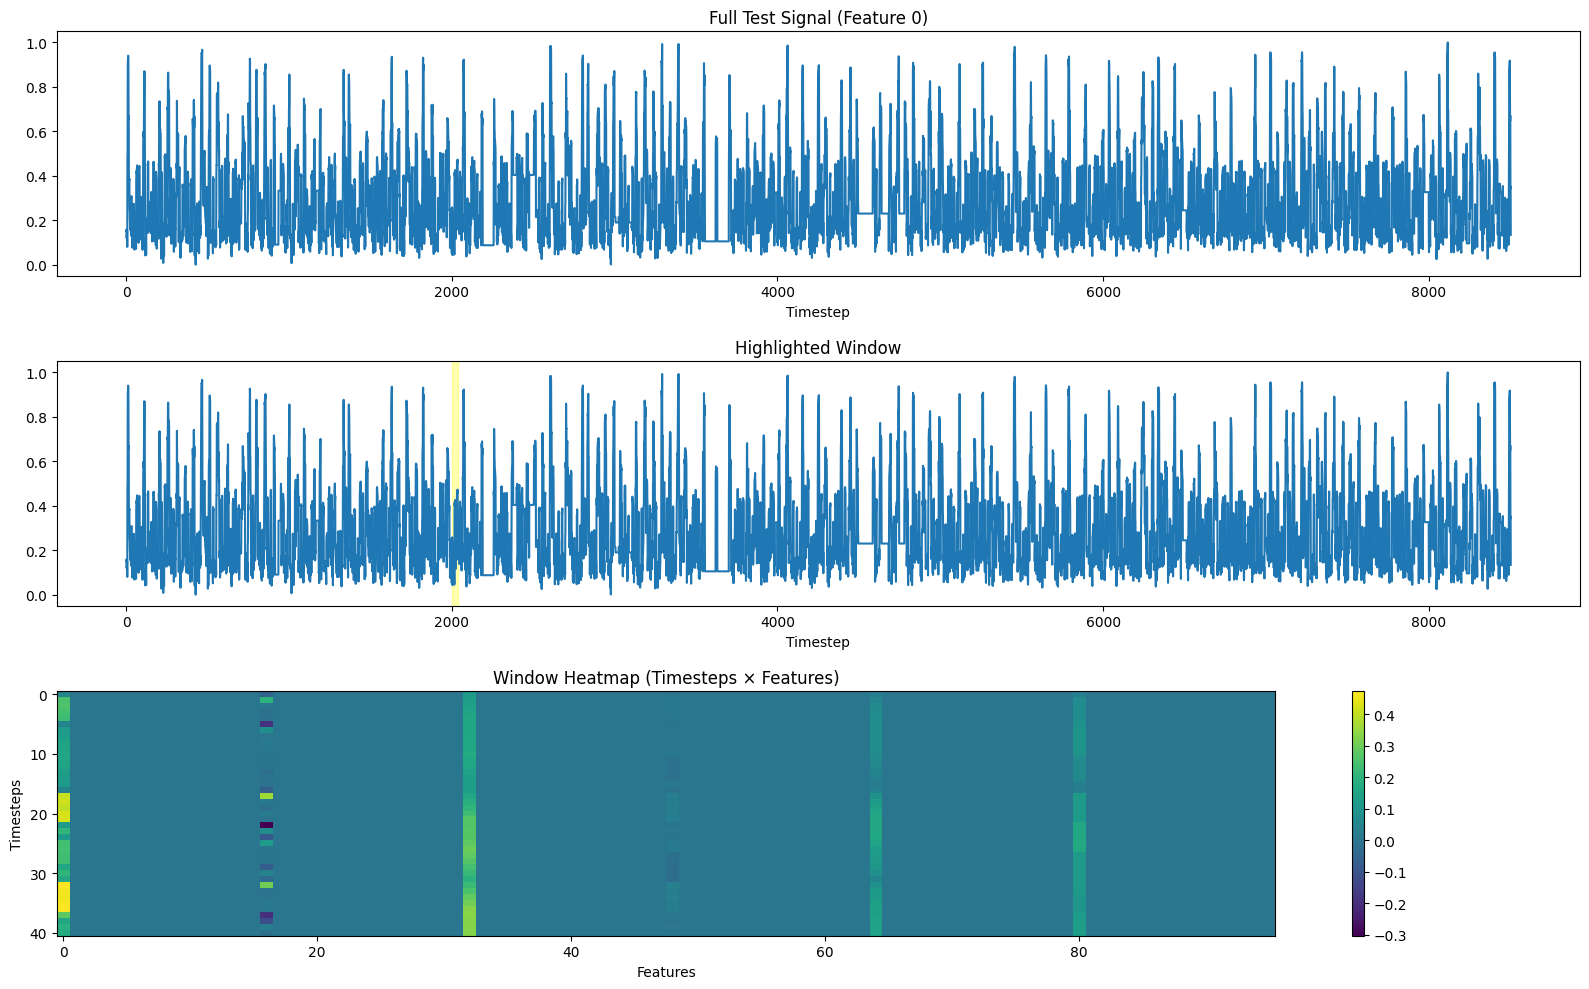

In [17]:
feature = 0
window_index = 2000

window = X_test_processed[
    window_index:window_index + window_size
]

fig, ax = plt.subplots(3, 1, figsize=(16,10))

# Panel 1 — Full test signal
ax[0].plot(X_test_processed[:, feature])
ax[0].set_title("Full Test Signal (Feature 0)")
ax[0].set_xlabel("Timestep")

# Panel 2 — Highlighted window
ax[1].plot(X_test_processed[:, feature])

ax[1].axvspan(
    window_index,
    window_index + window_size,
    color='yellow',
    alpha=0.3
)

ax[1].set_title("Highlighted Window")
ax[1].set_xlabel("Timestep")

# Panel 3 — Window heatmap
im = ax[2].imshow(
    window,
    aspect="auto",
    cmap="viridis"
)

fig.colorbar(im, ax=ax[2])

ax[2].set_title("Window Heatmap (Timesteps × Features)")
ax[2].set_xlabel("Features")
ax[2].set_ylabel("Timesteps")

# ADD THIS LINE FOR SPACING
plt.tight_layout()

# (optional but better)
plt.subplots_adjust(hspace=0.35)

# Save plot
os.makedirs("results/plots", exist_ok=True)

plt.savefig(
    "results/plots/P1_sequence_sample.png",
    dpi=150
)

plt.show()

### Sequence Visualization

### This visualization illustrates how the raw time series is converted into
### model-ready sequences.

### Panel 1: Full signal of feature 0 across the test dataset  
### Panel 2: A selected window highlighted within the signal  
### Panel 3: Heatmap representation of the sequence window where:

### - rows represent timesteps
### - columns represent features

### This confirms that the sequence generation process correctly captures
### temporal context across multiple features.

## Sequence Creation Function

In [18]:
import numpy as np

def create_sequences(data, window_size=30):

    sequences = []

    for i in range(len(data) - window_size):
        seq = data[i:i+window_size]
        sequences.append(seq)

    return np.array(sequences)

## Load Processed Data

In [19]:
import os

print(os.listdir("data/processed"))

['P-1_train.npy', 'P-1_test.npy']


In [21]:
channel_id = "P-1" # Corrected channel ID

X_train = np.load(f"data/sequences/{channel_id}_train_seq.npy")
X_val = np.load(f"data/sequences/{channel_id}_val_seq.npy")

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (2547, 41, 96)
Val: (284, 41, 96)


## Generate Sequences

In [22]:
window_size = 30

X_train_seq = create_sequences(X_train, window_size)
X_val_seq = create_sequences(X_val, window_size)

print("Train sequences:", X_train_seq.shape)
print("Val sequences:", X_val_seq.shape)

Train sequences: (2517, 30, 41, 96)
Val sequences: (254, 30, 41, 96)


## Save Sequences

In [23]:
np.save(f"data/sequences/{channel_id}_train_sequences.npy", X_train_seq)
np.save(f"data/sequences/{channel_id}_val_sequences.npy", X_val_seq)

print("Sequences saved")

Sequences saved


## Verify Files

In [24]:
!ls data/sequences

P-1_test_seq.npy   P-1_train_sequences.npy  P-1_val_sequences.npy
P-1_train_seq.npy  P-1_val_seq.npy
